# Assignment 2: Recursive Feature Elimination with Linear Regression
**MATH/CSCI 485 - Rowan Morkner**

## Task 1: Dataset Exploration

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X.shape, diabetes.feature_names

((442, 10), ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'])

In [12]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [13]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((353, 10), (89, 10))

## Task 2: Linear Regression Model

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

full_r2 = r2_score(y_test, lr.predict(X_test))
print("R2:", round(full_r2, 4))

pd.Series(lr.coef_, index=X.columns).round(2)

R2: 0.4526


age     37.90
sex   -241.96
bmi    542.43
bp     347.70
s1    -931.49
s2     518.06
s3     163.42
s4     275.32
s5     736.20
s6      48.67
dtype: float64

## Task 3: Recursive Feature Elimination

In [15]:
# Manual RFE: fit, get coefficients, eliminate smallest, repeat
feature_names = list(X.columns)
r2_scores = []
coef_history = []
eliminated_order = []

features_remaining = list(range(len(feature_names)))
X_tr = X_train.values
X_te = X_test.values

for n_feat in range(len(feature_names), 0, -1):
    model = LinearRegression()
    model.fit(X_tr[:, features_remaining], y_train)
    y_pred = model.predict(X_te[:, features_remaining])
    
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    
    coefs = np.zeros(len(feature_names))
    for i, idx in enumerate(features_remaining):
        coefs[idx] = model.coef_[i]
    coef_history.append(coefs)
    
    # eliminate the feature with smallest absolute coefficient
    if n_feat > 1:
        min_idx = np.argmin(np.abs(model.coef_))
        eliminated_order.append(feature_names[features_remaining[min_idx]])
        features_remaining.pop(min_idx)

print("Elimination order:", eliminated_order)

Elimination order: ['age', 's6', 's3', 's4', 'sex', 'bp', 's2', 's1', 's5']


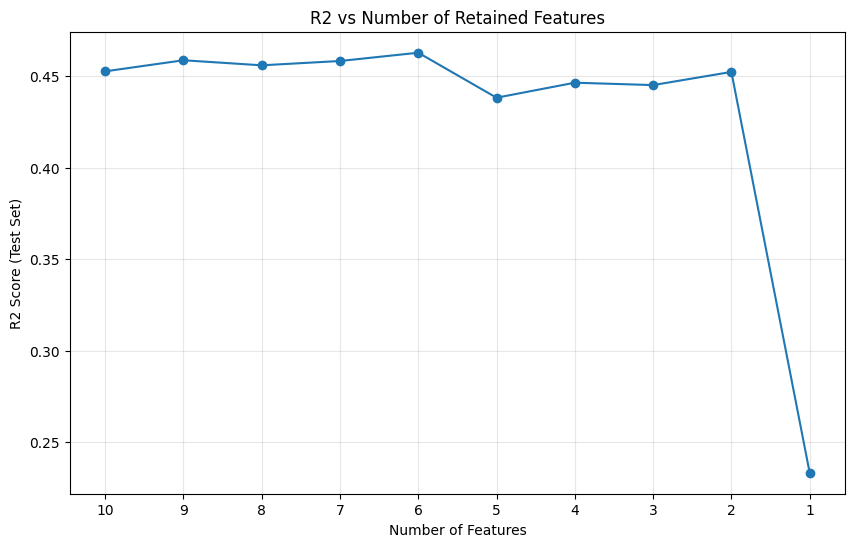

In [16]:
# R2 vs number of features
n_features_range = list(range(len(feature_names), 0, -1))

plt.figure(figsize=(10, 6))
plt.plot(n_features_range, r2_scores, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('R2 Score (Test Set)')
plt.title('R2 vs Number of Retained Features')
plt.xticks(n_features_range)
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()
plt.show()

In [17]:
# Optimal number of features (threshold = 0.01 improvement in R2)
threshold = 0.01
optimal_n = 1
for i in range(len(r2_scores) - 2, -1, -1):
    n_feat = len(feature_names) - i
    if r2_scores[i] - r2_scores[i + 1] >= threshold:
        optimal_n = n_feat

print("Optimal features:", optimal_n)
print("R2 at optimal:", round(r2_scores[len(feature_names) - optimal_n], 4))

Optimal features: 6
R2 at optimal: 0.4628


## Task 4: Feature Importance Analysis

In [8]:
# Coefficient table across iterations
coef_df = pd.DataFrame(coef_history, columns=feature_names,
                        index=[f"{n} feat" for n in n_features_range])
coef_df.round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
10 feat,37.9,-241.96,542.43,347.70,-931.49,518.06,163.42,275.32,736.20,48.67
9 feat,0.0,-236.65,542.80,354.21,-936.35,528.80,167.80,270.40,744.45,53.35
8 feat,0.0,-233.75,550.74,363.79,-947.82,541.59,172.25,277.74,761.92,0.00
7 feat,0.0,-235.36,551.87,362.36,-660.64,343.35,0.00,185.14,664.77,0.00
6 feat,0.0,-215.27,557.31,350.18,-851.52,591.09,0.00,0.00,803.12,0.00
5 feat,0.0,0.00,597.89,306.65,-655.56,409.62,0.00,0.00,728.64,0.00
4 feat,0.0,0.00,691.46,0.00,-592.98,362.95,0.00,0.00,783.17,0.00
3 feat,0.0,0.00,737.69,0.00,-228.34,0.00,0.00,0.00,680.22,0.00
2 feat,0.0,0.00,732.11,0.00,0.00,0.00,0.00,0.00,562.23,0.00
1 feat,0.0,0.00,998.58,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
# Top 3 features (last 3 surviving)
top_3 = [f for f in feature_names if f not in eliminated_order[:len(feature_names)-3]]
print("Top 3:", top_3)
print("Elimination order:", eliminated_order)

Top 3: ['bmi', 's1', 's5']
Elimination order: ['age', 's6', 's3', 's4', 'sex', 'bp', 's2', 's1', 's5']


### Discussion

The top 3 features from RFE are **bmi**, **s1**, and **s5**:

- **bmi** (Body Mass Index): a well-known risk factor for diabetes, linked to insulin resistance.
- **s1** (total serum cholesterol): important for metabolic health and diabetes complications.
- **s5** (log of serum triglycerides): elevated triglycerides are linked to metabolic syndrome.

The initial coefficient ranking and the RFE ranking agree on the top 3. This consistency suggests these features are robustly important even when correlated features are present.

## Task 5: Reflection

**1. What did you learn about feature selection using RFE?**

RFE iteratively removes the least important feature based on model coefficients. Removing features doesn't always hurt performance -- R2 stayed stable or even improved as noisy features were dropped. It gives a clear ranking and helps find a minimal effective feature set.

**2. How does RFE compare to LASSO?**

RFE is a wrapper method (retrain and eliminate one at a time), while LASSO is an embedded method (L1 penalty zeros out coefficients in one pass). LASSO is faster but depends on choosing the right alpha. RFE gives an explicit elimination order, making it easy to pick any number of features.

**3. What insights can you draw about the dataset?**

The dataset's effective dimensionality is much lower than 10. Body composition (bmi) and blood lipid markers (s1, s5) are the primary predictors, which aligns with medical understanding. Several blood serum features are correlated and can be removed without losing predictive power.